# Ideal planar biaxial test — SPINN parameter identification

Identification of Neo-Hookean and Gasser-Ogden-Holzapfel parameters from an **idealised**planar biaxial test: a 7 x 7 mm sample with the affine displacement field prescribed onthe whole boundary, over the 16-state protocol of thesis Table 3.1.Reference data: FEniCS, `src/phd/fem/biaxial_test.py`.Model: `phd.models.cm.biaxial_test` (SPINN, mixed formulation, loading state as a thirdnetwork input).Set `MODE = "run"` to retrain; the default loads the saved runs.

In [32]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import scienceplots  # optional, requires latex
plt.style.use(['science', 'grid'])

from phd.config import load_config
import phd.models.cm.biaxial_test as bt
from phd.models.cm.biaxial_test import parameter_summary
from phd.plot import get_current_config as plt_cfg, book_config

book_config.set_as_current()
page_width = plt_cfg().page_width

save_fig = False          # set True to write figures next to this notebook


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")


PROJECT_ROOT = find_project_root(Path.cwd())
NB_DIR = PROJECT_ROOT / "projects" / "FIBER" / "SPINN"
IMAGE_DIR = NB_DIR / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_ROOT = PROJECT_ROOT / "results" / "biaxial_test"
print(f"Project root: {PROJECT_ROOT}")
print(f"Results root: {RESULTS_ROOT}")
print("available runs:", sorted(p.name for p in RESULTS_ROOT.glob("*")) if RESULTS_ROOT.exists() else "none")

Project root: /home/r2d2/damien/PhD
Results root: /home/r2d2/damien/PhD/results/biaxial_test
available runs: ['GOH_inverse', 'NH_inverse']


In [2]:
def plot_parameter_evolution(results, fig=None, ax=None, title=None):
    """Trace of each identified parameter against its ground truth."""
    logger = results["callbacks"]["variable_value"]
    mat = results["material"]
    names = mat["parameter_names"]

    steps = np.array([h[0] for h in logger.history])
    # history rows are [step, v1, ..., vn]; take the whole tail so this stays
    # 2-D for a single-parameter law such as NH
    values = np.array([h[1:] for h in logger.history], dtype=float)

    if ax is None:
        fig, ax = plt.subplots(1, len(names),
                               figsize=(page_width, page_width * 0.26),
                               dpi=200, gridspec_kw={"wspace": 0.45})
        ax = np.atleast_1d(ax)

    for i, name in enumerate(names):
        truth = mat["true"][name]
        ax[i].plot(steps, values[:, i], lw=1.2)
        ax[i].axhline(truth, color="k", ls="--", lw=0.9)
        ax[i].set_title(f"{name}", fontsize=9)
        ax[i].set_xlabel("iteration", fontsize=8)
        ax[i].tick_params(labelsize=7)
    ax[0].set_ylabel("value", fontsize=8)
    if title:
        fig.suptitle(title, fontsize=10)
    return fig, ax


def parameter_table(results):
    df = parameter_summary(results)
    df.attrs["law"] = results["material"]["law"]
    return df


def plot_loss_history(results, fig=None, ax=None):
    """Loss components, labelled by what they actually constrain."""
    lh = results["losshistory"]
    steps = np.asarray(lh.steps)
    loss = np.asarray(lh.loss_train)
    labels = results.get("loss_labels", [f"loss {i}" for i in range(loss.shape[1])])

    if ax is None:
        fig, ax = plt.subplots(figsize=(page_width * 0.6, page_width * 0.35), dpi=200)
    for i, lab in enumerate(labels[: loss.shape[1]]):
        ax.semilogy(steps, loss[:, i], lw=1.0, label=lab)
    ax.set_xlabel("iteration", fontsize=8)
    ax.set_ylabel("loss", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, ncol=2, frameon=False)
    return fig, ax


def plot_fields(X, Y, fields, names, suptitle=None, cmap="viridis", ref=None):
    """Field maps; with `ref` supplied, a second row shows the reference."""
    n = len(names)
    rows = 2 if ref is not None else 1
    fig, ax = plt.subplots(rows, n, figsize=(page_width, page_width * 0.3 * rows),
                           dpi=200, squeeze=False, constrained_layout=True)
    for j, name in enumerate(names):
        im = ax[0][j].pcolormesh(X, Y, fields[name], cmap=cmap, shading="auto")
        ax[0][j].set_aspect("equal")
        ax[0][j].set_title(name, fontsize=9)
        ax[0][j].tick_params(labelsize=6)
        fig.colorbar(im, ax=ax[0][j], shrink=0.8).ax.tick_params(labelsize=6)
        if ref is not None:
            im2 = ax[1][j].pcolormesh(X, Y, ref[name], cmap=cmap, shading="auto")
            ax[1][j].set_aspect("equal")
            ax[1][j].set_title(f"{name} (reference)", fontsize=9)
            ax[1][j].tick_params(labelsize=6)
            fig.colorbar(im2, ax=ax[1][j], shrink=0.8).ax.tick_params(labelsize=6)
    if suptitle:
        fig.suptitle(suptitle, fontsize=10)
    return fig, ax

## 1. Load (or run) the two identifications

In [3]:
MODE = "load"          # "load" or "run"

RUNS = {"nh": "NH_inverse", "goh": "GOH_inverse"}
N_ITER = {"nh": 20000, "goh": 40000}

results = {}
for law, run_name in RUNS.items():
    if MODE == "run":
        r = bt.train(overrides=[
            f"problem.material.law={law}",
            f"training.n_iter={N_ITER[law]}",
            "training.log_every=500",
            "results.save_on_disk=true",
            f"results.experiment_name={run_name}",
        ])
    else:
        r = bt.load_run(run_name)
    results[law] = r
    print(f"[{law}] {MODE}: {r['run_dir']}")

[nh] load: /home/r2d2/damien/PhD/results/biaxial_test/NH_inverse
[goh] load: /home/r2d2/damien/PhD/results/biaxial_test/GOH_inverse


## 2. Identified parameters

In [9]:
tables = {}
for law, r in results.items():
    df = parameter_table(r)
    tables[law] = df
    print(f"===== {law.upper()}  (MPE = {df.attrs['MPE [%]']:.2f} %) =====")
    print(df.round(5).to_string())
    display(df.round(5))

===== NH  (MPE = 0.10 %) =====
  parameter  ground truth  identified  rel. error [%]
0       C10           0.4      0.4004         0.10079


,parameter,ground truth,identified,rel. error [%]
0,C10,0.4,0.4004,0.10079


===== GOH  (MPE = 16.47 %) =====
   parameter  ground truth  identified  rel. error [%]
0        C10         0.019     0.00555        70.79229
1         k1         5.150     4.91835         4.49807
2         k2         8.640     8.34359         3.43066
3      kappa         0.240     0.23355         2.68557
4  alpha_deg        38.800    39.16701         0.94590


,parameter,ground truth,identified,rel. error [%]
0,C10,0.019,0.00555,70.79229
1,k1,5.150,4.91835,4.49807
2,k2,8.640,8.34359,3.43066
3,kappa,0.240,0.23355,2.68557
4,alpha_deg,38.800,39.16701,0.94590


`C10` is the outlier for GOH and this is a property of the experiment, not of the fit —see the synthesis in `README_ideal_biaxial.md`.

## 3. Parameter evolution

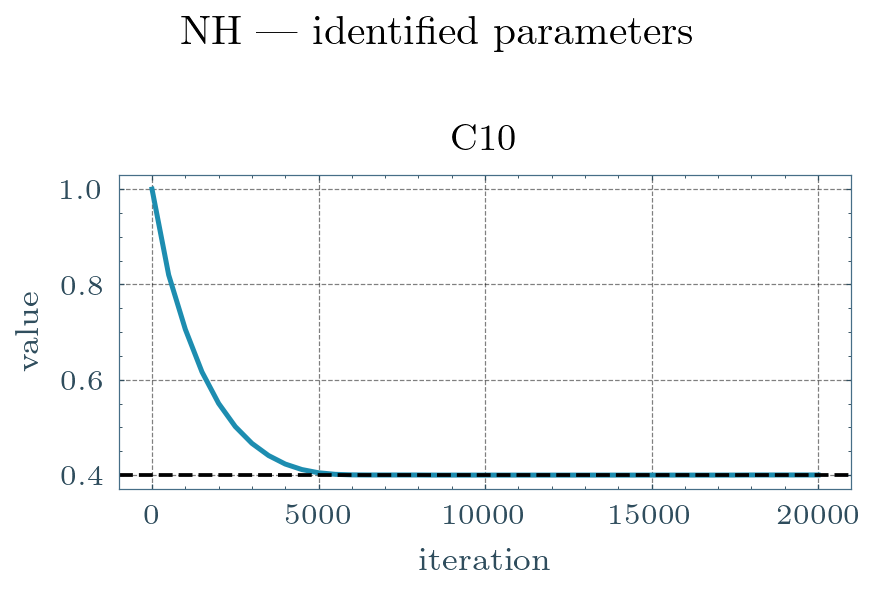

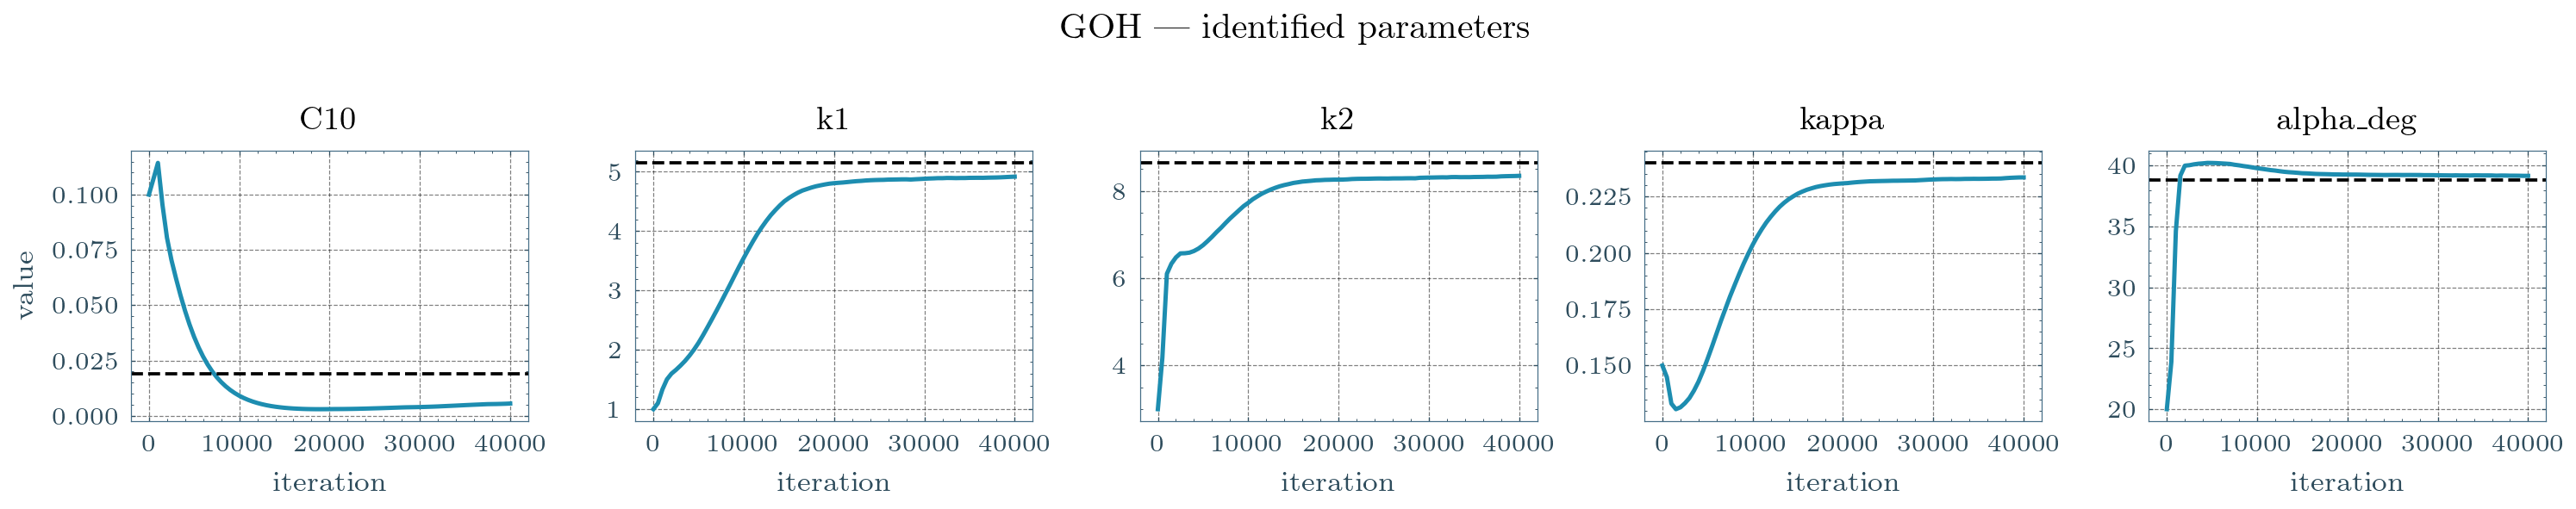

In [34]:
for law, r in results.items():
    n_param = len(r["external_vars"])
    fig, ax = plt.subplots(1, n_param, figsize=(max(n_param*2, 3), 2), dpi=300)
    ax = np.atleast_1d(ax)
    fig, ax = plot_parameter_evolution(r, fig=fig, ax=ax, title=f"{law.upper()} — identified parameters")
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    if save_fig:
        fig.savefig(IMAGE_DIR / f"ideal_{law}_parameters.png", bbox_inches="tight", dpi=300)
    plt.show()

In [17]:
r["external_vars"]

{'var_0': Array(-5.1940536, dtype=float32),
 'var_1': Array(1.592973, dtype=float32),
 'var_2': Array(2.1214936, dtype=float32),
 'var_3': Array(0.85046136, dtype=float32),
 'var_4': Array(-0.26071087, dtype=float32)}

## 4. Loss history`eq_*` are the equilibrium residuals, `const_*` the constitutive ones, `measure_*` thedisplacement and edge-force data.

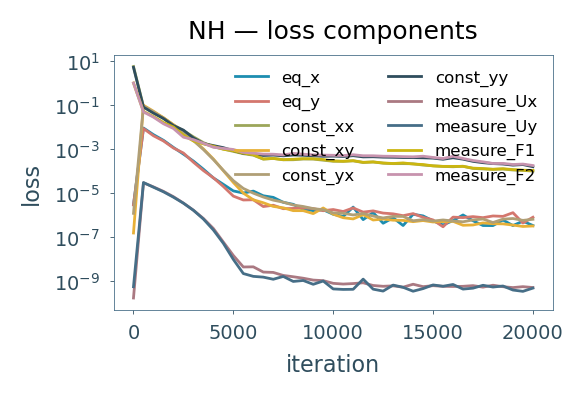

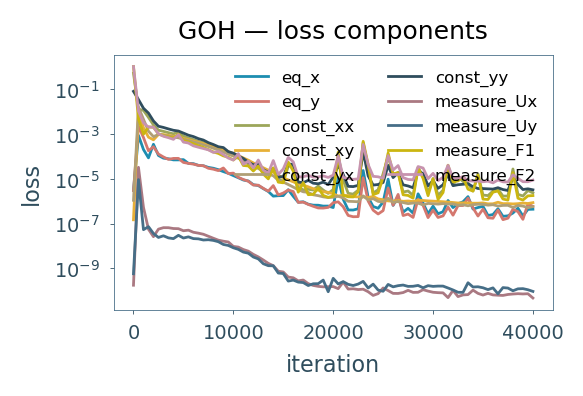

In [6]:
for law, r in results.items():
    fig, ax = plot_loss_history(r)
    ax.set_title(f"{law.upper()} — loss components", fontsize=9)
    plt.show()

## 5. Fields at the largest loading stateRequires the network, so this cell reloads with `restore_model=True` (or reuses thein-memory model when `MODE = "run"`).

Restoring model from saved parameters...
Set the default automatic differentiation to forward mode.


Compiling model...


'compile' took 3.617920 s



Training model...



Step      Train loss                                                                                              Test loss                                                                                               Test metric


0         [3.02e-06, 2.96e-06, 5.61e+00, 1.58e-07, 1.23e-06, 5.16e+00, 1.78e-10, 5.76e-10, 1.00e+00, 1.00e+00]    [3.02e-06, 2.96e-06, 5.61e+00, 1.58e-07, 1.23e-06, 5.16e+00, 1.78e-10, 5.76e-10, 1.00e+00, 1.00e+00]    []  



Best model at step 0:
  train loss: 1.28e+01
  test loss: 1.28e+01
  test metric: []

'train' took 7.062341 s



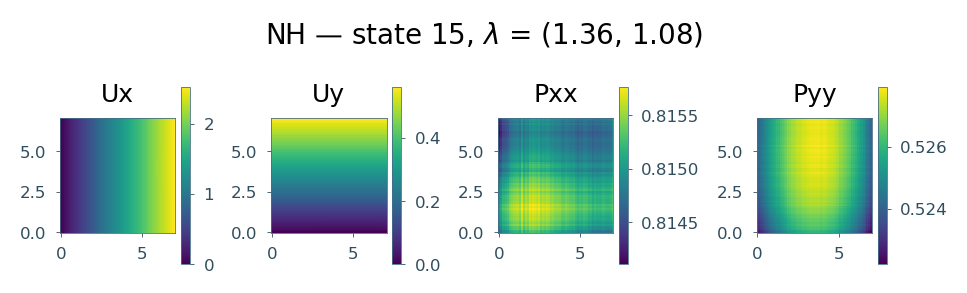

Restoring model from saved parameters...
Set the default automatic differentiation to forward mode.
Compiling model...
'compile' took 0.124247 s



Training model...



Step      Train loss                                                                                              Test loss                                                                                               Test metric


0         [3.02e-06, 2.96e-06, 5.05e-01, 1.46e-07, 1.09e-06, 7.82e-02, 1.78e-10, 5.76e-10, 1.00e+00, 1.00e+00]    [3.02e-06, 2.96e-06, 5.05e-01, 1.46e-07, 1.09e-06, 7.82e-02, 1.78e-10, 5.76e-10, 1.00e+00, 1.00e+00]    []  



Best model at step 0:
  train loss: 2.58e+00
  test loss: 2.58e+00
  test metric: []

'train' took 7.385839 s



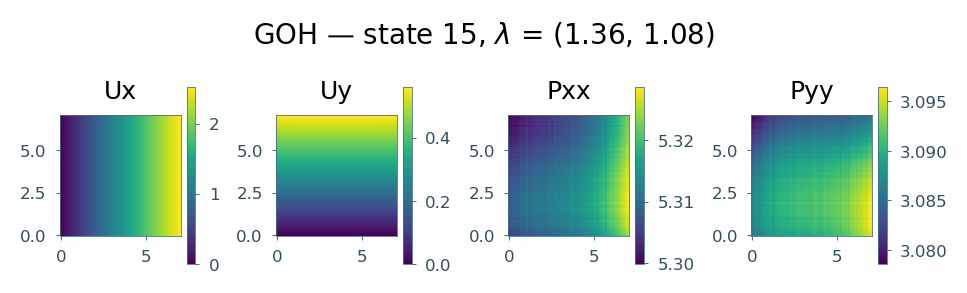

In [7]:
SHOW_FIELDS = True

if SHOW_FIELDS:
    for law, run_name in RUNS.items():
        r = results[law] if MODE == "run" else bt.load_run(run_name, restore_model=True)
        last = len(r["reference"]["states"]) - 1
        lam = r["reference"]["states"][last]
        X, Y, fields = bt.predict_state(r, last, n_grid=60)
        fig, ax = plot_fields(X, Y, fields, ["Ux", "Uy", "Pxx", "Pyy"],
                              suptitle=f"{law.upper()} — state {last}, "
                                       f"$\\lambda$ = ({lam[0]:.2f}, {lam[1]:.2f})")
        if save_fig:
            fig.savefig(IMAGE_DIR / f"ideal_{law}_fields.png", bbox_inches="tight", dpi=300)
        plt.show()

## 6. Do the identified parameters reproduce the measured forces?The edge force is the observable the parameters are identified from, so this is thecheck that matters.

Restoring model from saved parameters...
Set the default automatic differentiation to forward mode.
Compiling model...
'compile' took 0.116217 s



Training model...



Step      Train loss                                                                                              Test loss                                                                                               Test metric


0         [3.02e-06, 2.96e-06, 5.61e+00, 1.58e-07, 1.23e-06, 5.16e+00, 1.78e-10, 5.76e-10, 1.00e+00, 1.00e+00]    [3.02e-06, 2.96e-06, 5.61e+00, 1.58e-07, 1.23e-06, 5.16e+00, 1.78e-10, 5.76e-10, 1.00e+00, 1.00e+00]    []  



Best model at step 0:
  train loss: 1.28e+01
  test loss: 1.28e+01
  test metric: []

'train' took 6.613290 s



NH: mean relative force error  F1 0.598%   F2 0.980%


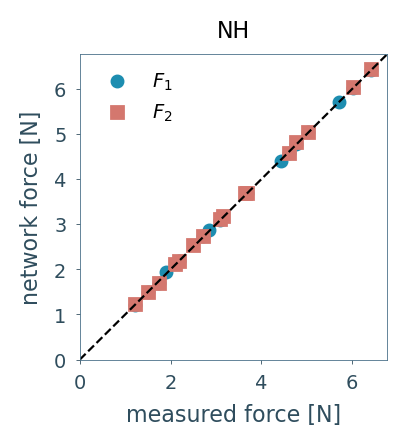

Restoring model from saved parameters...
Set the default automatic differentiation to forward mode.
Compiling model...
'compile' took 0.121090 s



Training model...



Step      Train loss                                                                                              Test loss                                                                                               Test metric


0         [3.02e-06, 2.96e-06, 5.05e-01, 1.46e-07, 1.09e-06, 7.82e-02, 1.78e-10, 5.76e-10, 1.00e+00, 1.00e+00]    [3.02e-06, 2.96e-06, 5.05e-01, 1.46e-07, 1.09e-06, 7.82e-02, 1.78e-10, 5.76e-10, 1.00e+00, 1.00e+00]    []  



Best model at step 0:
  train loss: 2.58e+00
  test loss: 2.58e+00
  test metric: []

'train' took 6.986492 s



GOH: mean relative force error  F1 0.249%   F2 0.311%


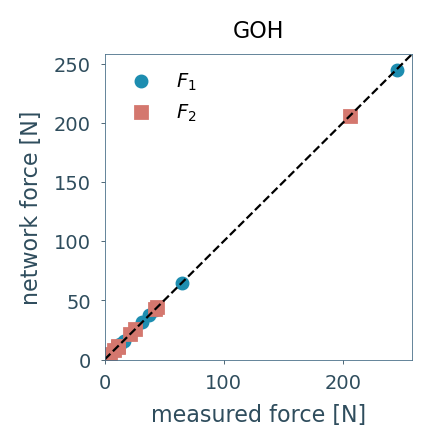

In [8]:
for law, run_name in RUNS.items():
    r = results[law] if MODE == "run" else bt.load_run(run_name, restore_model=True)
    pred = bt.predicted_forces(r)
    meas = r["reference"]["force"]
    rel = np.abs(pred - meas) / np.abs(meas)
    print(f"{law.upper()}: mean relative force error  F1 {rel[:,0].mean():.3%}   "
          f"F2 {rel[:,1].mean():.3%}")

    fig, ax = plt.subplots(figsize=(page_width * 0.42, page_width * 0.42), dpi=200)
    ax.plot(meas[:, 0], pred[:, 0], "o", ms=4, label="$F_1$")
    ax.plot(meas[:, 1], pred[:, 1], "s", ms=4, label="$F_2$")
    lim = [0, max(meas.max(), pred.max()) * 1.05]
    ax.plot(lim, lim, "k--", lw=0.8)
    ax.set(xlabel="measured force [N]", ylabel="network force [N]",
           xlim=lim, ylim=lim, title=law.upper())
    ax.legend(fontsize=7, frameon=False)
    ax.tick_params(labelsize=7)
    plt.show()